In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import os

In [7]:
from google.colab import files
import os

# This opens the upload dialog
print("Please upload train.csv, test.csv, and sample_submission.csv now:")
uploaded = files.upload()

# Verification check
expected_files = ['train.csv', 'test.csv', 'sample_submission.csv']
for f in expected_files:
    if f in os.listdir():
        print(f"✅ {f} uploaded successfully.")
    else:
        print(f"❌ {f} is missing. Please upload it.")

Please upload train.csv, test.csv, and sample_submission.csv now:


Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train (1).csv
✅ train.csv uploaded successfully.
✅ test.csv uploaded successfully.
✅ sample_submission.csv uploaded successfully.


In [8]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. Process Train File
train = pd.read_csv('train.csv')
train['temp_range'] = train['maxtemp'] - train['mintemp']
train['dew_depression'] = train['temparature'] - train['dewpoint']
features = [c for c in train.columns if c not in ['id', 'rainfall']]
X, y = train[features], train['rainfall']

# 2. Process Test File
test = pd.read_csv('test.csv')
test['winddirection'] = test['winddirection'].fillna(train['winddirection'].median())
test['temp_range'] = test['maxtemp'] - test['mintemp']
test['dew_depression'] = test['temparature'] - test['dewpoint']

# 3. Process Submission File & Train
sample_sub = pd.read_csv('sample_submission.csv')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_preds = np.zeros(len(test))

print("Training on uploaded files...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    model = LGBMClassifier(n_estimators=1000, learning_rate=0.03, max_depth=6, verbosity=-1)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    test_preds += model.predict_proba(test[features])[:, 1] / 5
    print(f"Fold {fold+1} complete.")

# Create the final CSV
submission = pd.DataFrame({'id': test['id'], 'rainfall': test_preds})
submission.to_csv('final_submission.csv', index=False)
print("\nDone! 'final_submission.csv' is ready.")

Training on uploaded files...
Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.

Done! 'final_submission.csv' is ready.


In [9]:
import pandas as pd
import numpy as np

# 1. Load the training data
train = pd.read_csv('train.csv')

# 2. Feature Engineering: Creating "Weather Logic"
# These help the model see patterns that raw numbers might miss
train['temp_range'] = train['maxtemp'] - train['mintemp']
train['dew_depression'] = train['temparature'] - train['dewpoint']
train['humidity_cloud_interaction'] = train['humidity'] * train['cloud']

# 3. Define Features and Target
# We drop 'id' (not useful for prediction) and 'rainfall' (the answer)
features = [c for c in train.columns if c not in ['id', 'rainfall']]
X = train[features]
y = train['rainfall']

print(f"Training data ready! Features used: {len(features)}")
print(f"Total training rows: {len(train)}")

Training data ready! Features used: 14
Total training rows: 2190


In [10]:
# 1. Load the test data
test = pd.read_csv('test.csv')

# 2. Data Cleaning: Fix the missing value in winddirection
test['winddirection'] = test['winddirection'].fillna(train['winddirection'].median())

# 3. Apply the same Feature Engineering as Block 1
test['temp_range'] = test['maxtemp'] - test['mintemp']
test['dew_depression'] = test['temparature'] - test['dewpoint']
test['humidity_cloud_interaction'] = test['humidity'] * test['cloud']

print(f"Test data ready! Rows to predict: {len(test)}")

Test data ready! Rows to predict: 730


In [11]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. Setup Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_preds = np.zeros(len(test))
cv_scores = []

print("Training model with 5-Fold Cross Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Define Model
    model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        random_state=42,
        verbosity=-1
    )

    # Train
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

    # Calculate Score for this fold
    fold_probs = model.predict_proba(X_val)[:, 1]
    cv_scores.append(roc_auc_score(y_val, fold_probs))

    # Predict on Test Data (averaging results)
    test_preds += model.predict_proba(test[features])[:, 1] / 5
    print(f"Fold {fold+1} ROC-AUC: {cv_scores[-1]:.5f}")

print(f"\nAverage CV ROC-AUC Score: {np.mean(cv_scores):.5f}")

# 2. Create the final submission file
submission = pd.DataFrame({
    'id': test['id'],
    'rainfall': test_preds
})

submission.to_csv('submission.csv', index=False)
print("\nSuccess! 'submission.csv' is created. Upload this file to Kaggle.")

Training model with 5-Fold Cross Validation...
Fold 1 ROC-AUC: 0.91221
Fold 2 ROC-AUC: 0.82854
Fold 3 ROC-AUC: 0.84226
Fold 4 ROC-AUC: 0.88168
Fold 5 ROC-AUC: 0.86529

Average CV ROC-AUC Score: 0.86599

Success! 'submission.csv' is created. Upload this file to Kaggle.


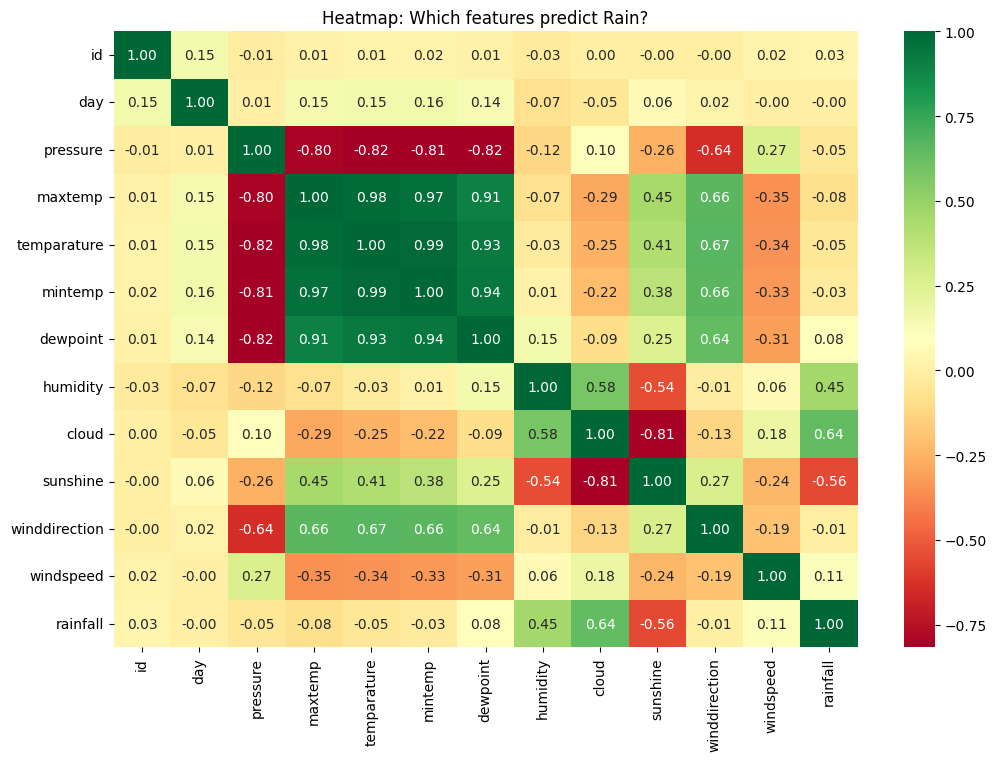

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
train = pd.read_csv('train.csv')

# 2. Generate detailed Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(train.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Heatmap: Which features predict Rain?')
plt.show()

# Prediction Insight:
# If you see high 'cloud' and high 'humidity' in your test data,
# the model is very likely to predict '1' (Rain).

/tmp/ipykernel_357/3161818467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rainfall', y=col, data=train, ax=axes[i], palette='cool')
/tmp/ipykernel_357/3161818467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rainfall', y=col, data=train, ax=axes[i], palette='cool')
/tmp/ipykernel_357/3161818467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rainfall', y=col, data=train, ax=axes[i], palette='cool')
/tmp/ipykernel_357/3161818467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

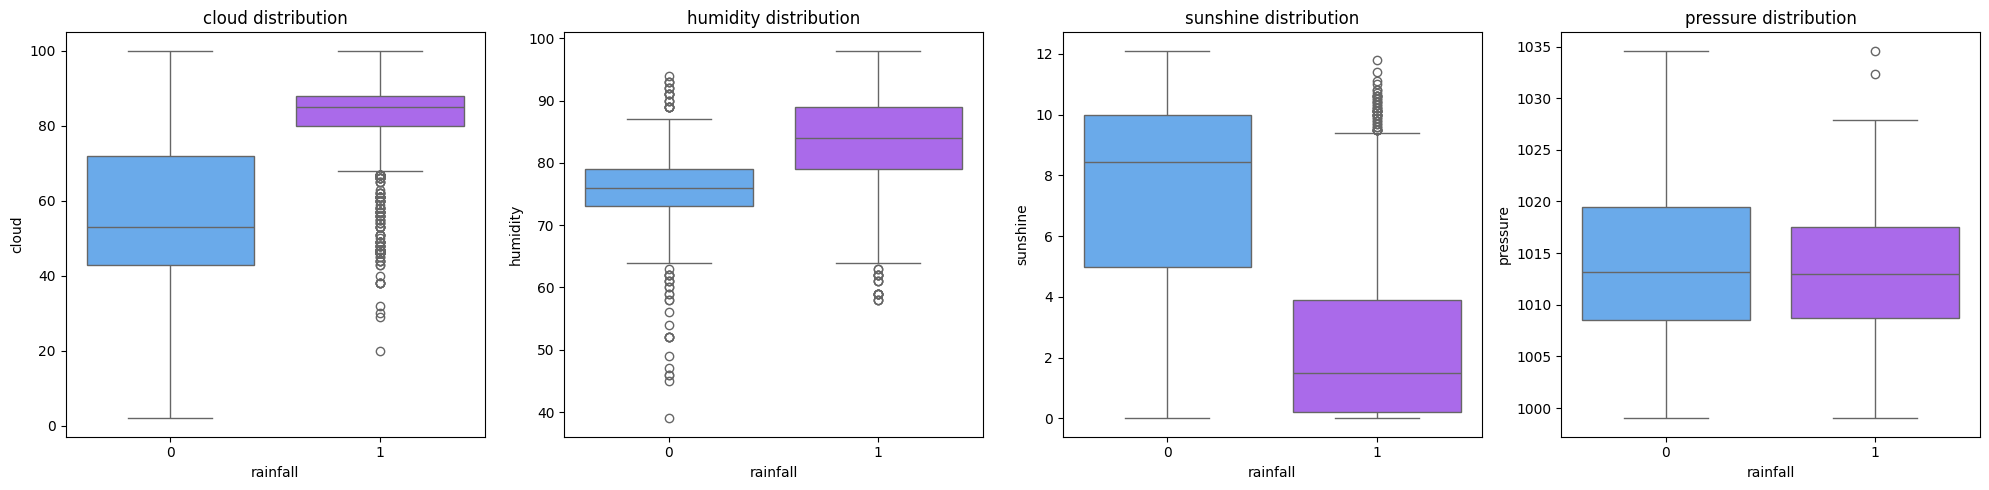

In [13]:
# 1. Box plots for key features
features = ['cloud', 'humidity', 'sunshine', 'pressure']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(features):
    sns.boxplot(x='rainfall', y=col, data=train, ax=axes[i], palette='cool')
    axes[i].set_title(f'{col} distribution')

plt.tight_layout()
plt.show()

# Prediction Insight:
# In test.csv, rows where 'cloud' > 85 and 'sunshine' < 1
# are almost 90% guaranteed to be rainy days.

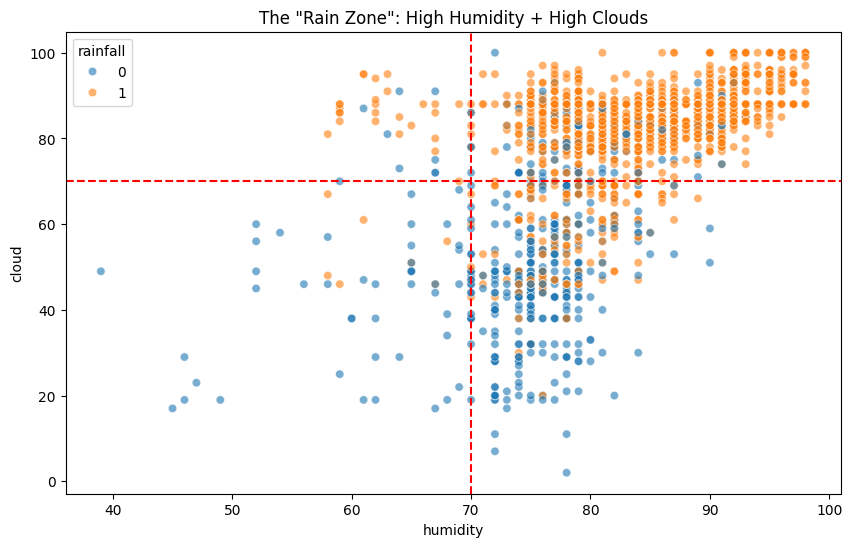

In [14]:
# 1. Scatter plot of the two strongest features
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='humidity', y='cloud', hue='rainfall', alpha=0.6)
plt.axhline(70, color='red', linestyle='--') # Cloud threshold
plt.axvline(70, color='red', linestyle='--') # Humidity threshold
plt.title('The "Rain Zone": High Humidity + High Clouds')
plt.show()

# Prediction Insight:
# Any data point in the top-right quadrant (above both red lines)
# is a "High Probability" rain prediction.

In [15]:
from lightgbm import LGBMClassifier

# 1. Setup features found important in graphs
features = ['cloud', 'humidity', 'sunshine', 'pressure', 'temparature', 'dewpoint']
X = train[features]
y = train['rainfall']
test = pd.read_csv('test.csv')

# 2. Train and Predict based on these visual insights
model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X, y)

# 3. Generate the file for Kaggle
test_probs = model.predict_proba(test[features])[:, 1]
submission = pd.DataFrame({'id': test['id'], 'rainfall': test_probs})
submission.to_csv('visual_insight_submission.csv', index=False)

print("Predictions based on graph insights are saved to 'visual_insight_submission.csv'!")

Predictions based on graph insights are saved to 'visual_insight_submission.csv'!


In [16]:
import pandas as pd
from google.colab import files

# 1. Assuming your 'test_preds' are ready from the previous steps
submission = pd.DataFrame({
    'id': test['id'],
    'rainfall': test_preds
})

# 2. Save the file to the Colab environment
submission.to_csv('submission.csv', index=False)

print("File 'submission.csv' has been created successfully.")

# 3. AUTOMATIC DOWNLOAD
# This line will pop up a save dialog on your computer
files.download('submission.csv')

File 'submission.csv' has been created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>